# Issue #706, "scale_alpha: conflict of constant and mapped values of alpha aesthetic"

When a layer uses a constant numeric aesthetic (e.g. `geom_point(alpha=0.5)`) alongside another layer
that maps the same aesthetic to data with a non-identity transform (e.g. `scale_alpha(trans='log10')`),
the constant was incorrectly run through the transform, producing a wrong value. For alpha this often meant
a negative value that was later clamped to 0.


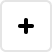
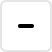
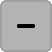
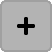
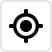
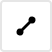
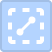
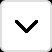
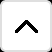
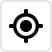
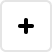
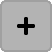
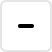
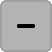
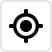
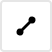
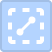
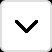
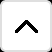
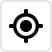

In [1]:
from lets_plot import *

LetsPlot.setup_html()

data = {
    'x': [-3, -2, -1, 0, 1, 2, 3],
    'y': [-3, -2, -1, 0, 1, 2, 3],
    # negative and zero values are outside log10 domain; only 1, 4, 9 survive
    'v': [-9, -4, -1, 0, 1, 4, 9],
}

## 1. Original failing case: constant `alpha=0.5` + `scale_alpha(trans='log10')`

Before the fix the large blue points (Layer 1) were invisible (alpha clamped to 0).
After the fix they should appear at 50% opacity.

ggplot2 behavior: produces a warning about out-of-domain values but renders both layers.

In [2]:
(
    ggplot(data, aes('x', 'y'))
    + geom_point(size=10, alpha=0.5)            # constant alpha - must stay 0.5
    + geom_point(aes(alpha='v'), color='black') # mapped alpha through log10
    + scale_alpha(trans='log10')
    + ggtitle('Original case: constant alpha=0.5 + log10 transform')
)

## 2. `trans='sqrt'` - wrong value before, correct after

With `sqrt`, `sqrt(0.5) ~= 0.707` fell inside [0,1] so points were visible but at the wrong
opacity. After the fix the large blue points must appear at exactly 50% opacity.


In [3]:
(
    ggplot(data, aes('x', 'y'))
    + geom_point(size=10, alpha=0.5)
    + geom_point(aes(alpha='v'), color='black')
    + scale_alpha(trans='sqrt')
    + ggtitle('Constant alpha=0.5 + sqrt transform (was ~0.71 before fix)')
)

## 3. `trans='reverse'` - negated constant before, correct after

The `reverse` transform maps `v` to `-v`. With the old code the constant 0.5 became -0.5
(clamped to 0). After the fix it stays 0.5.


In [4]:
data_pos = {
    'x': [1, 2, 3, 4, 5],
    'y': [1, 2, 3, 4, 5],
    'v': [0.1, 0.3, 0.5, 0.7, 0.9],
}

(
    ggplot(data_pos, aes('x', 'y'))
    + geom_point(size=10, alpha=0.5)
    + geom_point(aes(alpha='v'), color='black')
    + scale_alpha(trans='reverse')
    + ggtitle('Constant alpha=0.5 + reverse transform')
)

## 4. Regression: constant alpha, no scale transform

Without a transform the constant must pass through unchanged. Both layers visible.

In [5]:
(
    ggplot(data, aes('x', 'y'))
    + geom_point(size=10, alpha=0.5)            # constant - must remain 0.5
    + geom_point(aes(alpha='v'), color='black') # mapped, identity transform
    + scale_alpha()
    + ggtitle('Regression: constant alpha + identity transform (no change expected)')
)


## 5. Regression: mapped alpha with `log10`, no constant layer

This worked before and must continue to work. Only positive `v` values (1, 4, 9) are mapped;
the rest render with the NA alpha.

In [6]:
(
    ggplot(data, aes('x', 'y'))
    + geom_point(aes(alpha='v'), color='steelblue', size=8)
    + scale_alpha(trans='log10')
    + ggtitle('Regression: only mapped alpha + log10 (no constant layer)')
)

## 6. Positional constant on a log10 x-scale (must still be transformed)

Unlike non-positional constants, a positional constant such as `xintercept=10` on a log10
x-axis must be transformed (so it appears at the correct position on the log scale).
Verify `geom_vline(xintercept=10)` appears at x=10 on the log10 x-axis.

In [7]:
data_pos2 = {'x': [1, 2, 5, 10, 50, 100], 'y': [1, 2, 3, 4, 5, 6]}

(
    ggplot(data_pos2, aes('x', 'y'))
    + geom_point(size=4)
    + geom_vline(xintercept=10, color='red', linetype='dashed')  # must align with x=10 points
    + scale_x_log10()
    + ggtitle('Positional constant (xintercept=10) on log10 x-axis - must stay at x=10')
)

## 7. Two mapped layers sharing `scale_alpha(trans='log10')`

Both layers use `aes(alpha=...)`. Neither has a constant. Both must render correctly.

In [8]:
import numpy as np

data_a = {'x': [1, 2, 3, 4, 5], 'y': [2, 2, 2, 2, 2], 'v': [1, 2, 3, 4, 5]}
data_b = {'x': [1, 2, 3, 4, 5], 'y': [4, 4, 4, 4, 4], 'w': [5, 4, 3, 2, 1]}

(
    ggplot()
    + geom_point(aes('x', 'y', alpha='v'), data=data_a, color='steelblue', size=8)
    + geom_point(aes('x', 'y', alpha='w'), data=data_b, color='tomato',    size=8)
    + scale_alpha(trans='log10')
    + ggtitle('Two mapped layers sharing scale_alpha(trans=log10)')
)

## 8. Constant alpha outside [0,1] with a log10-mapped layer

A constant `alpha > 1` or `alpha < 0` is clamped by the renderer regardless of transforms.
Verify no exception is thrown and the clamping is applied without the transform distorting things.

In [9]:
# alpha=1.5 -> clamped to 1.0 (fully opaque)
(
    ggplot(data, aes('x', 'y'))
    + geom_point(size=10, alpha=1.5)            # clamped to 1.0
    + geom_point(aes(alpha='v'), color='black')
    + scale_alpha(trans='log10')
    + ggtitle('Constant alpha=1.5 (clamped to 1.0) + log10 mapped layer')
)


In [10]:
# alpha=0.0 -> fully transparent (large points invisible by design)
(
    ggplot(data, aes('x', 'y'))
    + geom_point(size=10, alpha=0.0)            # fully transparent
    + geom_point(aes(alpha='v'), color='black')
    + scale_alpha(trans='log10')
    + ggtitle('Constant alpha=0.0 (fully transparent) + log10 mapped layer')
)


## 9. Other non-positional constant aesthetics with a transform

The same bug could affect any numeric non-positional constant paired with a mapped scale
that carries a transform. Check `size` (constant) + `scale_size(trans='log10')`.

In [11]:
data_sz = {
    'x': [1, 2, 3, 4, 5],
    'y': [3, 3, 3, 3, 3],
    'v': [1, 2, 5, 10, 50],
}

(
    ggplot(data_sz, aes('x', 'y'))
    # constant size=5 must remain size=5 regardless of scale_size transform
    + geom_point(size=5, color='steelblue', alpha=0.5)
    + geom_point(aes(size='v'), color='tomato', alpha=0.5)
    + scale_size(trans='log10')
    + ggtitle('Constant size=5 + scale_size(trans=log10) - size must not be distorted')
)


## 10. Coordinate-derived constant: `slope` is positional already

`slope` is not a scale-mapped visual property like alpha or size. It is treated as positional by
`Aes.isPositional()`, so it keeps the positional constant path without a separate special case in
`constantMapperOption`. The wide plot below is a quick visual sanity check for a constant
`geom_abline(slope=1)` line.


In [12]:
data_slope = {
    'x': [0, 1, 2, 3, 4, 5],
    'y': [0, 1, 2, 3, 4, 5],
}

(
    ggplot(data_slope, aes('x', 'y'))
    + geom_point(size=5, color='black')
    + geom_abline(slope=1, intercept=0, color='red', size=1.2)
    + ggsize(760, 260)
    + ggtitle('Constant slope=1 keeps coordinate mapper in a wide plot')
)
